In [6]:
import warnings
warnings.filterwarnings("ignore")  # suppress sklearn warnings for cleaner output

import json
from pathlib import Path
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_auc_score, roc_curve)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")



In [2]:
df = pd.read_csv("../data/synthetic_billing.csv")
print(df.head(5))

   patient_id  patient_age insurance_type  procedure_cpt_code diagnosis_code  \
0           1           19        Private               99213          M79.3   
1           1           19        Private               97110          M25.5   
2           2           70        Private               99214            R51   
3           1           19        Private               85025         Z00.00   
4           2           70        Private               99281          E11.9   

   billed_amount  days_since_last_claim  num_prior_claims  prior_denial_rate  \
0         144.33                    999                 0                0.0   
1         127.01                    115                 1                1.0   
2         151.39                    999                 0                0.0   
3          66.42                     93                 2                0.5   
4         186.26                     94                 1                0.0   

   is_code_mismatch  is_high_cost_proc

In [3]:
print("Anomaly breakdown by generator rules:\n")

print("Billed Amount Statistics:")
print(df.groupby("anomaly_label")["billed_amount"].describe().round(2))

print("\nDays Since Last Claim:")
print(df.groupby("anomaly_label")["days_since_last_claim"].describe().round(2))

print("\nNum Prior Claims:")
print(df.groupby("anomaly_label")["num_prior_claims"].describe().round(2))

print("\n\nEngineered Flags in Anomalies:")
for col in ["is_code_mismatch", "is_high_cost_procedure", "is_frequent_claimer", "is_recent_repeat_claim"]:
    print(f"\n{col}:")
    print(df.groupby(col)["anomaly_label"].mean().round(3))

Anomaly breakdown by generator rules:

Billed Amount Statistics:
                 count    mean     std    min    25%     50%     75%      max
anomaly_label                                                                
0              17913.0  159.73  153.38  18.28  97.06  123.84  161.97  1598.36
1               2087.0  160.58  153.40  18.10  97.38  126.01  162.45  1546.66

Days Since Last Claim:
                 count    mean     std  min   25%    50%    75%    max
anomaly_label                                                         
0              17913.0  329.87  400.08  7.0  65.0  124.0  999.0  999.0
1               2087.0  227.62  356.36  1.0   9.0   83.0  157.0  999.0

Num Prior Claims:
                 count  mean   std  min  25%  50%  75%   max
anomaly_label                                               
0              17913.0  2.88  3.40  0.0  0.0  2.0  4.0  34.0
1               2087.0  3.40  3.55  0.0  1.0  2.0  5.0  24.0


Engineered Flags in Anomalies:

is_code_mismatch:


In [5]:
features_for_iso = [
    "patient_age", 
    "billed_amount",
    "days_since_last_claim",
    "num_prior_claims",
    "prior_denial_rate",
    "is_code_mismatch",
    "is_high_cost_procedure",
    "is_frequent_claimer",
    "is_recent_repeat_claim",
]


X_iso = df[features_for_iso].copy()
y_true = df['anomaly_label'].values

print(f"\n\nFeature Isolation Forest: {len(features_for_iso)} features used")
print(f"Shape: {X_iso.shape}")
print(f"\nFeature ranges: ")
display(X_iso.describe().round(3))

scaler = StandardScaler()
X_iso_scaled = scaler.fit_transform(X_iso)
print(f"\nScaled Feature Ranges: {X_iso_scaled.shape}")



Feature Isolation Forest: 9 features used
Shape: (20000, 9)

Feature ranges: 


,patient_age,billed_amount,days_since_last_claim,num_prior_claims,prior_denial_rate,is_code_mismatch,is_high_cost_procedure,is_frequent_claimer,is_recent_repeat_claim
count,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000
mean,53.235,159.815,319.202,2.937,0.258,0.127,0.040,0.048,0.025
std,21.580,153.376,396.971,3.422,0.344,0.333,0.195,0.213,0.156
min,16.000,18.100,1.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,35.000,97.110,61.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,53.000,124.035,121.000,2.000,0.000,0.000,0.000,0.000,0.000
75%,72.000,162.002,999.000,4.000,0.500,0.000,0.000,0.000,0.000
max,90.000,1598.360,999.000,34.000,1.000,1.000,1.000,1.000,1.000



Scaled Feature Ranges: (20000, 9)


In [8]:
contamination_rates = [0.05, 0.08, 0.10, 0.12, 0.15]
results = []

for contamination in contamination_rates:
    iso = IsolationForest (
        contamination=contamination,
        random_state=42,
        n_estimators=100,
        n_jobs=-1
    )
    
    y_pred_iso = iso.fit_predict(X_iso_scaled)
    y_pred_binary = (y_pred_iso == -1).astype(int)  # Convert to 0/1
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_binary).ravel()
    
    metrics = {
        "contamination": contamination,
        "precision": precision_score(y_true, y_pred_binary),
        "recall": recall_score(y_true, y_pred_binary),
        "f1_score": f1_score(y_true, y_pred_binary),
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn)
    }
    results.append(metrics)
    
comparison = pd.DataFrame(results)
comparison = pd.DataFrame(results)
display(comparison.style.format({c: "{:.4f}" for c in ["precision", "recall", "f1"]}))

,contamination,precision,recall,f1_score,tp,tn,fp,fn
0,0.050000,0.3100,0.1485,0.200842,310,17223,690,1777
1,0.080000,0.3419,0.2621,0.296718,547,16860,1053,1540
2,0.100000,0.3275,0.3138,0.320529,655,16568,1345,1432
3,0.120000,0.2863,0.3292,0.306218,687,16200,1713,1400
4,0.150000,0.2437,0.3503,0.287399,731,15644,2269,1356


In [9]:

optimal_contamination = 0.08  # adjust based on Cell 5 output

iso_best = IsolationForest(
    contamination=optimal_contamination,
    random_state=42,
    n_estimators=100,
    n_jobs=-1
)

y_pred_iso = iso_best.fit_predict(X_iso_scaled)
y_pred_iso_binary = (y_pred_iso == -1).astype(int)

# Get anomaly scores (negative = more anomalous)
anomaly_scores = iso_best.score_samples(X_iso_scaled)

print(f"Chose contamination: {optimal_contamination}")
print(f"Predicted anomalies: {y_pred_iso_binary.sum()} ({y_pred_iso_binary.mean():.2%})")
print(f"True anomalies: {y_true.sum()} ({y_true.mean():.2%})\n")

print("Confusion Matrix:")
cm = confusion_matrix(y_true, y_pred_iso_binary)
print(cm)
print(f"\nClassification Report:")
print(classification_report(y_true, y_pred_iso_binary, target_names=["Normal", "Anomaly"]))

Chose contamination: 0.08
Predicted anomalies: 1600 (8.00%)
True anomalies: 2087 (10.44%)

Confusion Matrix:
[[16860  1053]
 [ 1540   547]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.94      0.93     17913
     Anomaly       0.34      0.26      0.30      2087

    accuracy                           0.87     20000
   macro avg       0.63      0.60      0.61     20000
weighted avg       0.86      0.87      0.86     20000



In [10]:
def apply_rule_filters(df_input, features_df):
    """
    Rule-based anomaly detection layer.
    Combines with Isolation Forest for hybrid approach.
    """
    flags = []
    
    for idx, row in df_input.iterrows():
        anomaly_score = 0
        reason = []
        
        # Rule 1: Zero or extreme billed amounts
        if row["billed_amount"] == 0 or row["billed_amount"] > 50000:
            anomaly_score += 1
            reason.append("extreme_amount")
        
        # Rule 2: Recent repeat claim (same patient, same procedure within 7 days)
        # For notebook, we'll use is_recent_repeat_claim flag as proxy
        if row["is_recent_repeat_claim"] == 1:
            anomaly_score += 1
            reason.append("recent_repeat")
        
        # Rule 3: Amount outlier (> 2.5 std from mean for that CPT)
        cpt = row["procedure_cpt_code"]
        cpt_mean = df_input[df_input["procedure_cpt_code"] == cpt]["billed_amount"].mean()
        cpt_std = df_input[df_input["procedure_cpt_code"] == cpt]["billed_amount"].std()
        
        if cpt_std > 0 and abs(row["billed_amount"] - cpt_mean) > 2.5 * cpt_std:
            anomaly_score += 0.5
            reason.append("amount_outlier")
        
        # Rule 4: High priority risk (both code mismatch AND frequent claimer)
        if row["is_code_mismatch"] == 1 and row["is_frequent_claimer"] == 1:
            anomaly_score += 1
            reason.append("high_risk_combo")
        
        flags.append({
            "rule_anomaly_score": anomaly_score,
            "rule_reason": " | ".join(reason) if reason else "normal"
        })
    
    return pd.DataFrame(flags)

rule_flags = apply_rule_filters(df, df[features_for_iso])
print("Rule-based anomalies detected:")
print(rule_flags["rule_anomaly_score"].value_counts().sort_index())
print(f"\nRecords flagged by rules: {(rule_flags['rule_anomaly_score'] > 0).sum()}")

# Combine Isolation Forest + Rules
df["iso_forest_pred"] = y_pred_iso_binary
df["iso_forest_score"] = anomaly_scores
df["rule_score"] = rule_flags["rule_anomaly_score"]
df["rule_reason"] = rule_flags["rule_reason"]

# Hybrid: flag if EITHER isolation forest OR rules flag it (high recall) or BOTH (high precision)
# For now, use OR logic (catch more potential issues)
df["final_anomaly_flag"] = ((df["iso_forest_pred"] == 1) | (df["rule_score"] > 0)).astype(int)

print(f"\nFinal hybrid flagged: {df['final_anomaly_flag'].sum()}")

Rule-based anomalies detected:
rule_anomaly_score
0.0    19408
0.5        1
1.0      568
2.0       23
Name: count, dtype: int64

Records flagged by rules: 592

Final hybrid flagged: 1675


In [11]:
y_pred_final = df["final_anomaly_flag"].values

print("HYBRID MODEL (Isolation Forest + Rules) Evaluation:\n")

cm_final = confusion_matrix(y_true, y_pred_final)
print("Confusion Matrix:")
print(cm_final)

print(f"\nClassification Report:")
print(classification_report(y_true, y_pred_final, target_names=["Normal", "Anomaly"], digits=4))

# Breakdown comparison
print("\n\nComparison: Isolation Forest vs Hybrid:")
comparison_final = pd.DataFrame({
    "Model": ["Isolation Forest Only", "Isolation Forest + Rules"],
    "Precision": [
        precision_score(y_true, y_pred_iso_binary, zero_division=0),
        precision_score(y_true, y_pred_final, zero_division=0)
    ],
    "Recall": [
        recall_score(y_true, y_pred_iso_binary, zero_division=0),
        recall_score(y_true, y_pred_final, zero_division=0)
    ],
    "F1": [
        f1_score(y_true, y_pred_iso_binary, zero_division=0),
        f1_score(y_true, y_pred_final, zero_division=0)
    ]
})
display(comparison_final.style.format({c: "{:.4f}" for c in ["Precision", "Recall", "F1"]}))

HYBRID MODEL (Isolation Forest + Rules) Evaluation:

Confusion Matrix:
[[16859  1054]
 [ 1466   621]]

Classification Report:
              precision    recall  f1-score   support

      Normal     0.9200    0.9412    0.9305     17913
     Anomaly     0.3707    0.2976    0.3301      2087

    accuracy                         0.8740     20000
   macro avg     0.6454    0.6194    0.6303     20000
weighted avg     0.8627    0.8740    0.8678     20000



Comparison: Isolation Forest vs Hybrid:


,Model,Precision,Recall,F1
0,Isolation Forest Only,0.3419,0.2621,0.2967
1,Isolation Forest + Rules,0.3707,0.2976,0.3301


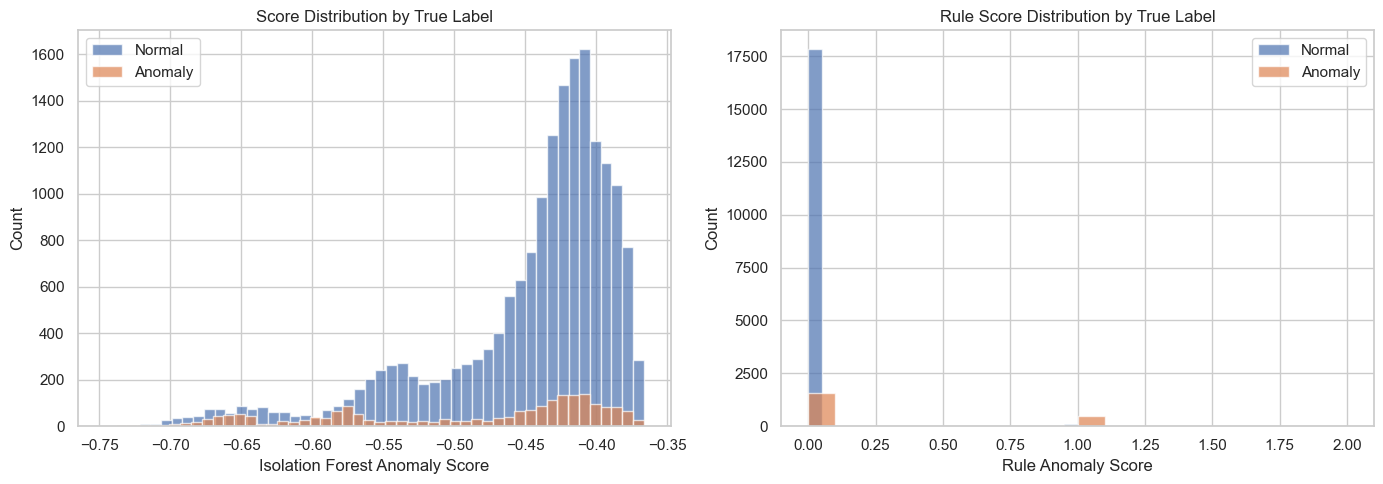

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Isolation Forest scores
axes[0].hist(df[df["anomaly_label"] == 0]["iso_forest_score"], bins=50, alpha=0.7, label="Normal")
axes[0].hist(df[df["anomaly_label"] == 1]["iso_forest_score"], bins=50, alpha=0.7, label="Anomaly")
axes[0].set_xlabel("Isolation Forest Anomaly Score")
axes[0].set_ylabel("Count")
axes[0].set_title("Score Distribution by True Label")
axes[0].legend()

# Rule scores
axes[1].hist(df[df["anomaly_label"] == 0]["rule_score"], bins=20, alpha=0.7, label="Normal")
axes[1].hist(df[df["anomaly_label"] == 1]["rule_score"], bins=20, alpha=0.7, label="Anomaly")
axes[1].set_xlabel("Rule Anomaly Score")
axes[1].set_ylabel("Count")
axes[1].set_title("Rule Score Distribution by True Label")
axes[1].legend()

plt.tight_layout()
plt.show()


In [13]:
# Show most anomalous records according to model
top_anomalies = df.nlargest(10, "rule_score")[
    ["patient_id", "billed_amount", "days_since_last_claim", 
     "num_prior_claims", "iso_forest_score", "rule_score", "rule_reason", "anomaly_label"]
]
print("Top 10 Records Flagged by Hybrid Model:\n")
display(top_anomalies)

print("\nBreakdown of rule reasons:")
print(df[df["final_anomaly_flag"] == 1]["rule_reason"].value_counts())

Top 10 Records Flagged by Hybrid Model:



,patient_id,billed_amount,days_since_last_claim,num_prior_claims,iso_forest_score,rule_score,rule_reason,anomaly_label
35,2,704.66,1,9,-0.745946,2.0,recent_repeat | high_risk_combo,1
980,7,180.92,2,13,-0.702948,2.0,recent_repeat | high_risk_combo,1
1648,65,97.14,5,6,-0.679719,2.0,recent_repeat | high_risk_combo,1
3507,412,29.94,6,4,-0.681530,2.0,recent_repeat | high_risk_combo,1
4174,53,35.45,2,10,-0.695727,2.0,recent_repeat | high_risk_combo,1
5396,123,150.03,6,6,-0.683408,2.0,recent_repeat | high_risk_combo,1
6753,1040,33.68,6,6,-0.685542,2.0,recent_repeat | high_risk_combo,1
6868,452,103.42,6,7,-0.694335,2.0,recent_repeat | high_risk_combo,1
6879,160,54.26,6,7,-0.686908,2.0,recent_repeat | high_risk_combo,1
6998,1199,35.30,4,5,-0.692688,2.0,recent_repeat | high_risk_combo,1



Breakdown of rule reasons:
rule_reason
normal                             1083
recent_repeat                       479
high_risk_combo                      89
recent_repeat | high_risk_combo      23
amount_outlier                        1
Name: count, dtype: int64


In [15]:
save_dir = Path("../../models/saved")
save_dir.mkdir(parents=True, exist_ok=True)

# Save Isolation Forest model
joblib.dump(iso_best, save_dir / "anomaly_model_iso.pkl")
joblib.dump(scaler, save_dir / "anomaly_model_scaler.pkl")

# Save feature list for API
joblib.dump(features_for_iso, save_dir / "anomaly_model_features.pkl")

# Metadata
metadata = {
    "model_type": "Isolation Forest + Rule-Based Hybrid",
    "training_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "dataset_size": int(len(df)),
    "features": features_for_iso,
    "contamination": optimal_contamination,
    "metrics": {
        "precision": round(precision_score(y_true, y_pred_final, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred_final, zero_division=0), 4),
        "f1_score": round(f1_score(y_true, y_pred_final, zero_division=0), 4),
    },
    "rules": [
        "zero_or_extreme_amount: billed_amount == 0 or > 50000",
        "recent_repeat: is_recent_repeat_claim == 1",
        "amount_outlier: abs(billed_amount - cpt_mean) > 2.5 * cpt_std",
        "high_risk_combo: is_code_mismatch == 1 AND is_frequent_claimer == 1"
    ]
}

with open(save_dir / "anomaly_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print(f"Artifacts saved to: {save_dir}")
print(f"   - anomaly_model_iso.pkl")
print(f"   - anomaly_model_scaler.pkl")
print(f"   - anomaly_model_features.pkl")
print(f"   - anomaly_model_metadata.json")

Artifacts saved to: ..\..\models\saved
   - anomaly_model_iso.pkl
   - anomaly_model_scaler.pkl
   - anomaly_model_features.pkl
   - anomaly_model_metadata.json


In [ ]:
# Simulate what the API will do

print("Testing model loading for API...\n")

# Load artifacts
iso_loaded = joblib.load(save_dir / "anomaly_model_iso.pkl")
scaler_loaded = joblib.load(save_dir / "anomaly_model_scaler.pkl")
features_loaded = joblib.load(save_dir / "anomaly_model_features.pkl")

with open(save_dir / "anomaly_model_metadata.json", "r") as f:
    metadata_loaded = json.load(f)

print(f"Model type: {metadata_loaded['model_type']}")
print(f"Precision: {metadata_loaded['metrics']['precision']}")
print(f"Recall: {metadata_loaded['metrics']['recall']}")

# Test on a random record
test_record = X_iso.iloc[0:1].values
test_scaled = scaler_loaded.transform(test_record)
test_pred = iso_loaded.predict(test_scaled)
test_score = iso_loaded.score_samples(test_scaled)

print(f"\nTest prediction on first record:")
print(f"  Isolation Forest prediction: {test_pred[0]} (1=anomaly, -1=normal)")
print(f"  Score: {test_score[0]:.4f}")
print("Model loads and predicts successfully!")

Testing model loading for API...

Model type: Isolation Forest + Rule-Based Hybrid
Precision: 0.3707
Recall: 0.2976

Test prediction on first record:
  Isolation Forest prediction: 1 (1=anomaly, -1=normal)
  Score: -0.4654
Model loads and predicts successfully!
